In [4]:
import os
import time
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    roc_curve,
    f1_score,
    recall_score,
    precision_score,
    classification_report
)
from random import randint, random, sample
from sklearn.tree import DecisionTreeClassifier

In [5]:
# Load training data set
df_train = pd.read_csv("KDD_Train_Set.csv")   # df -> our data frame of training data set
df_test = pd.read_csv("KDD_Test_Set.csv")   # df -> our data frame of testing data set


combined_df = pd.concat([df_train, df_test], axis=0, ignore_index=True)

### Recognizing data set

In [6]:
headers = list(combined_df.columns.values) # Return No. features(columns) names(values)
print(f"Headers: -\n{headers}\n")
print(f"Number of features: {len(headers) - 1}") # -1 As label column is not execluded
print(combined_df.head())    # Print 1st 5 elements in the given data
print(len(combined_df))      # Print the number of rows
print("Training data set description: -\n\n")
combined_df.info()
combined_df.describe().T   # Transpose it to make it easier to be read

Headers: -
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label']

Number of features: 41
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0

,count,mean,std,min,25%,50%,75%,max
duration,148516.0,276.781168,2.460691e+03,0.0,0.00,0.00,0.00,5.771500e+04
src_bytes,148516.0,40228.220158,5.409630e+06,0.0,0.00,44.00,278.00,1.379964e+09
dst_bytes,148516.0,17088.968657,3.703537e+06,0.0,0.00,0.00,571.00,1.309937e+09
land,148516.0,0.000215,1.467719e-02,0.0,0.00,0.00,0.00,1.000000e+00
wrong_fragment,148516.0,0.020523,2.400699e-01,0.0,0.00,0.00,0.00,3.000000e+00
urgent,148516.0,0.000202,1.941714e-02,0.0,0.00,0.00,0.00,3.000000e+00
hot,148516.0,0.189380,2.013167e+00,0.0,0.00,0.00,0.00,1.010000e+02
num_failed_logins,148516.0,0.004323,7.224847e-02,0.0,0.00,0.00,0.00,5.000000e+00
logged_in,148516.0,0.402792,4.904612e-01,0.0,0.00,0.00,1.00,1.000000e+00
num_compromised,148516.0,0.255063,2.223145e+01,0.0,0.00,0.00,0.00,7.479000e+03


In [7]:
num_classes  = combined_df['label'].nunique()
class_counts = combined_df['label'].value_counts()
print(f"Number of unique classes: {num_classes}")
print(f"Class counts: {class_counts}")
print(f"Remark total number of data rows is: {combined_df['label'].value_counts().sum()}")

Number of unique classes: 2
Class counts: label
0.0    77053
1.0    71463
Name: count, dtype: int64
Remark total number of data rows is: 148516


### Dealing with null values

In [8]:
null_train_counts = combined_df.isnull().sum().sum()
null_test_counts = combined_df.isnull().any().any()

print(f"Null values in our training data set: {null_train_counts}")# If it's zero so we don't need to know if every column has a null value or not
print(f"Does our testing set have any null values? {null_test_counts}")

# If there you can use one of these: -
# i) Remove rows with any null values
# data_no_null_rows = df_train.dropna() # As deafult axis = 0, so removed from rows

# ii) Remove columns with any null values
# data_no_null_columns = df_train.dropna(axis = 1)

# iii) Fill null value with the mean of the column W.R.T. this column that has null value
# data filled = df_test.fillna(df_test.mean())

Null values in our training data set: 0
Does our testing set have any null values? False


### Data pre-processing

In [9]:
combined_df1 = combined_df.copy()

dfDummies = pd.get_dummies(combined_df1["protocol_type"], prefix="protocol", dtype=float)
combined_df1 = pd.concat([combined_df1,dfDummies], axis=1)
combined_df1 = combined_df1.drop(["protocol_type"], axis=1)


dfDummies = pd.get_dummies(combined_df1["service"], prefix="service", dtype=float)
combined_df1 = pd.concat([combined_df1,dfDummies], axis=1)
combined_df1 = combined_df1.drop(["service"], axis=1)

dfDummies = pd.get_dummies(combined_df1["flag"], prefix="flag", dtype=float)
combined_df1 = pd.concat([combined_df1,dfDummies], axis=1)
combined_df1 = combined_df1.drop(["flag"], axis=1)

In [10]:
num_classes  = combined_df1['label'].nunique()
class_counts = combined_df1['label'].value_counts()
print(f"Number of unique classes: {num_classes}")
print(f"Class counts: {class_counts}")
print(f"Remark total number of data rows is: {combined_df1['label'].value_counts().sum()}")

Number of unique classes: 2
Class counts: label
0.0    77053
1.0    71463
Name: count, dtype: int64
Remark total number of data rows is: 148516


In [11]:
print(combined_df1.columns.values)

['duration' 'src_bytes' 'dst_bytes' 'land' 'wrong_fragment' 'urgent' 'hot'
 'num_failed_logins' 'logged_in' 'num_compromised' 'root_shell'
 'su_attempted' 'num_root' 'num_file_creations' 'num_shells'
 'num_access_files' 'num_outbound_cmds' 'is_host_login' 'is_guest_login'
 'count' 'srv_count' 'serror_rate' 'srv_serror_rate' 'rerror_rate'
 'srv_rerror_rate' 'same_srv_rate' 'diff_srv_rate' 'srv_diff_host_rate'
 'dst_host_count' 'dst_host_srv_count' 'dst_host_same_srv_rate'
 'dst_host_diff_srv_rate' 'dst_host_same_src_port_rate'
 'dst_host_srv_diff_host_rate' 'dst_host_serror_rate'
 'dst_host_srv_serror_rate' 'dst_host_rerror_rate'
 'dst_host_srv_rerror_rate' 'label' 'protocol_icmp' 'protocol_tcp'
 'protocol_udp' 'service_IRC' 'service_X11' 'service_Z39_50' 'service_aol'
 'service_auth' 'service_bgp' 'service_courier' 'service_csnet_ns'
 'service_ctf' 'service_daytime' 'service_discard' 'service_domain'
 'service_domain_u' 'service_echo' 'service_eco_i' 'service_ecr_i'
 'service_efs' 'ser

### Data scaling

In [12]:
y = combined_df1['label']

combined_df1 = combined_df1.drop(columns = 'label', axis = 1)

scaler = StandardScaler()
data_scaled = scaler.fit_transform(combined_df1)

# Convert the scaled data back to a pandas DataFrame
data_scaled = pd.DataFrame(data_scaled, columns=combined_df1.columns)

### Spliting the data

In [13]:

# Separate features and target
X = data_scaled
# Split the data
x_train, x_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,  # 20% for testing, 80% for training
    random_state=42,  # Ensure reproducibility
    stratify=y  # Ensure class distribution is maintained (optional, for classification problems)
)

### Drawing correlation graph

In [14]:
#corr = x_train.corr()
#fig, ax = plt.subplots(figsize = (50, 50))
#sns.heatmap(corr, cmap = 'Blues', annot = True)

In [15]:
headers = list(x_train.columns.values) # Return No. features(columns) names(values)
print(f"Headers: -\n{headers}\n")
print(f"Number of features: {len(headers) - 1}") # -1 As label column is not execluded

Headers: -
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'protocol_icmp', 'protocol_tcp', 'protocol_udp', 'service_IRC', 'service_X11', 'service_Z39_50', 'service_aol', 'service_auth', 'service_bgp', 'service_courier', 'service_csnet_ns', 'service_ctf', 'service_daytime', 'service_discard', 'service_domain', 'service_domain_u', 'service_echo', 'servic

In [16]:
threshold = 0.6
corr_matrix = x_train.corr().abs()

# Select the upper triangle of the correlation matrix
upper_triangle = corr_matrix.where(
    ~np.tril(np.ones(corr_matrix.shape)).astype(bool)
)

# Find features with a correlation higher than the threshold
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]

# Drop the identified features
reduced_x_train = x_train.drop(columns=to_drop)

In [17]:
headers = list(reduced_x_train.columns.values) # Return No. features(columns) names(values)
print(f"Headers: -\n{headers}\n")
print(f"Number of features: {len(headers) - 1}") # -1 As label column is not execluded

Headers: -
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'count', 'srv_count', 'serror_rate', 'rerror_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'protocol_icmp', 'protocol_tcp', 'service_IRC', 'service_X11', 'service_Z39_50', 'service_aol', 'service_auth', 'service_bgp', 'service_courier', 'service_csnet_ns', 'service_ctf', 'service_daytime', 'service_discard', 'service_domain', 'service_echo', 'service_efs', 'service_exec', 'service_finger', 'service_ftp_data', 'service_gopher', 'service_harvest', 'service_hostnames', 'service_http_2784', 'service_http_443', 'service_http_8001', 'service_imap4', 'service_iso_tsap', 'service_klogin', 'service_kshell', 'service_ldap', 's

In [18]:
print(set(reduced_x_train.columns) - set(x_test.columns))  # Features in x_train but not in x_test
print("=====================================================")
print(set(x_test.columns) - set(reduced_x_train.columns))  # Features in x_test but not in x_train

set()
{'service_domain_u', 'service_eco_i', 'num_root', 'dst_host_srv_serror_rate', 'service_ftp', 'service_ecr_i', 'same_srv_rate', 'flag_S0', 'dst_host_srv_rerror_rate', 'dst_host_serror_rate', 'flag_REJ', 'flag_SF', 'dst_host_same_srv_rate', 'dst_host_srv_count', 'service_http', 'dst_host_rerror_rate', 'is_guest_login', 'srv_rerror_rate', 'protocol_udp', 'srv_serror_rate'}


In [19]:
columns_to_droped = {'dst_host_same_srv_rate', 'flag_SF', 'dst_host_srv_count', 'service_http', 'service_eco_i', 'num_root', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'srv_rerror_rate', 'flag_REJ', 'srv_serror_rate', 'protocol_udp', 'dst_host_srv_rerror_rate', 'service_domain_u', 'service_ecr_i', 'flag_S0', 'service_ftp', 'is_guest_login', 'same_srv_rate', 'dst_host_serror_rate'}
x_test = x_test.drop(columns = columns_to_droped,  errors='ignore')

In [20]:
print(set(reduced_x_train.columns) - set(x_test.columns))  # Features in x_train but not in x_test
print("=====================================================")
print(set(x_test.columns) - set(reduced_x_train.columns))  # Features in x_test but not in x_train

set()
set()


### Training ML Models

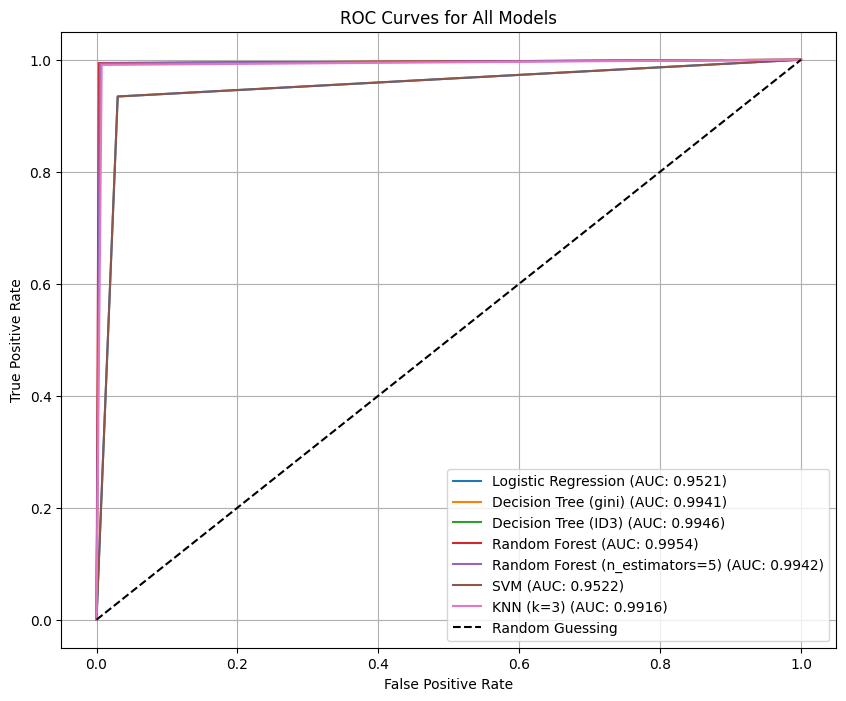

                               Training_Accuracy Testing_Accuracy  \
Logistic Regression                       0.9538           0.9528   
Decision Tree (gini)                      0.9991           0.9941   
Decision Tree (ID3)                       0.9991           0.9946   
Random Forest                             0.9991           0.9955   
Random Forest (n_estimators=5)            0.9987           0.9942   
SVM                                       0.9534           0.9528   
KNN (k=3)                                 0.9953           0.9917   

                               Balanced_Accuracy             ROC_AUC F1_Score  \
Logistic Regression                       0.9521  0.9520975705284341   0.9501   
Decision Tree (gini)                      0.9941    0.99412120401296   0.9939   
Decision Tree (ID3)                       0.9946  0.9946205583877159   0.9944   
Random Forest                             0.9954  0.9954068363814618   0.9953   
Random Forest (n_estimators=5)            

In [21]:
# Metrics and models configuration
evaluation_metrics = [
    "Training_Accuracy", "Testing_Accuracy", "Balanced_Accuracy", 
    "ROC_AUC", "F1_Score", "Recall", "Precision", 
    "Training_time", "Testing_time"
]

models = [
    "Logistic Regression", "Decision Tree (gini)", "Decision Tree (ID3)", 
    "Random Forest", "Random Forest (n_estimators=5)", "SVM", "KNN (k=3)"
]

df = pd.DataFrame(index=models, columns=evaluation_metrics)

# List of models to iterate
model_configs = [
    ("Logistic Regression", LogisticRegression(max_iter=1000)),
    ("Decision Tree (gini)", tree.DecisionTreeClassifier(criterion="gini")),
    ("Decision Tree (ID3)", tree.DecisionTreeClassifier(criterion="entropy")),
    ("Random Forest", RandomForestClassifier()),
    ("Random Forest (n_estimators=5)", RandomForestClassifier(n_estimators=5)),
    ("SVM", LinearSVC(C=1)),
    ("KNN (k=3)", KNeighborsClassifier(n_neighbors=3))
]

# Initialize a plot for ROC Curves
plt.figure(figsize=(10, 8))

# Train and evaluate each model
for model_name, model in model_configs:
    # Measure training time and train model
    start_train = time.time()
    model.fit(reduced_x_train, y_train)
    training_time = time.time() - start_train

    # Calculate Training Accuracy
    y_train_pred = model.predict(reduced_x_train)
    training_accuracy = accuracy_score(y_train, y_train_pred)

    # Measure testing time and predict on test set
    start_test = time.time()
    y_pred = model.predict(x_test)
    testing_time = time.time() - start_test

    # Calculate Testing Metrics
    testing_accuracy = accuracy_score(y_test, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
    try:
        roc_auc = roc_auc_score(y_test, y_pred)
    except ValueError:
        roc_auc = "N/A"  # Handle binary classification issue
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    # ROC Curve
    try:
        fpr, tpr, _ = roc_curve(y_test, y_pred)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC: {roc_auc:.4f})")
    except ValueError:
        print(f"ROC Curve could not be computed for {model_name}.")

    # Store results in DataFrame
    df.loc[model_name] = [
        f"{training_accuracy:.4f}", f"{testing_accuracy:.4f}", f"{balanced_accuracy:.4f}",
        f"{roc_auc}" if roc_auc != "N/A" else "N/A", f"{f1:.4f}",
        f"{recall:.4f}", f"{precision:.4f}", f"{training_time:.4f}s", f"{testing_time:.4f}s"
    ]

# Finalize the ROC Curve plot
plt.plot([0, 1], [0, 1], 'k--', label="Random Guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend(loc="lower right")
plt.grid()
plt.savefig("roc_curves_all_models.png")  # Save the plot
plt.show()

# Save metrics to Excel
df.to_excel("model_evaluation_metrics.xlsx")

# Print DataFrame
print(df)

In [22]:
# Convert scaled training data to DataFrame
x_train_scaled_df = pd.DataFrame(reduced_x_train, columns=reduced_x_train.columns)
# Add the 'label' column to the DataFrame
x_train_scaled_df['label'] = y_train
# Save to CSV
x_train_scaled_df.to_csv(r'KDD_Train_Set2.csv', index=False)


# Convert scaled data back to DataFrame
x_test_scaled_df = pd.DataFrame(x_test, columns=x_test.columns)
# Add the 'label' column to the DataFrame
x_test_scaled_df['label'] = y_test
# Save to CSV
x_test_scaled_df.to_csv(r'KDD_Test_Set2.csv', index=False)

# Genetic Algorithm Parameters Summary

## 1. Population Size (`populationSize = 20`)
Defines the number of individuals (solutions) in each generation. Larger sizes improve diversity but increase computation.

## 2. Number of Generations (`numGenerations = 15`)
Specifies how many iterations the algorithm will run. More generations allow better refinement but take longer.

## 3. Crossover Rate (`crossoverRate = 0.8`)
The probability (80%) that selected parent pairs will combine to create offspring, promoting exploration of new solutions.

## 4. Mutation Rate (`mutationRate = 0.1`)
The probability (10%) of randomly altering genes in an individual, maintaining diversity and avoiding local optima.

## 5. Use of Elitism (`useElitism = True`)
Ensures the best solutions are preserved for the next generation, preventing quality degradation in the population.

---

## Summary
These parameters balance **exploration** (finding new solutions) and **exploitation** (refining good ones) to optimize performance.


In [2]:
# parameters for the genetic algorithm
populationSize = 20 
numGenerations = 15
crossoverRate = 0.8 # it means 80% of the selected parent pairs will undergo crossover to produce offspring.
mutationRate = 0.1  # the probability of performing mutation on an individual’s genes to introduce small, random changes.
useElitism = True   # the best solution(s) from the current generation are guaranteed to survive and appear in the next generation.

# Explanation: Initializing Lists for Visualization

- **`best_fitness_history`**: Tracks the best fitness value per generation.
- **`feature_size_history`**: Tracks the feature size per generation.

These lists are used for visualizing the algorithm's performance over time.

In [26]:
# initialize lists for storing data for visualization
best_fitness_history = []
feature_size_history = []

# Explanation: Population Initialization

- **`numFeatures`**: The number of features in the dataset.
- **Population Initialization**: Creates a `populationSize x numFeatures` (20 x 102) binary array where each entry is either 0 or 1, representing the initial population for the genetic algorithm.


In [27]:
numFeatures = reduced_x_train.shape[1]

# 2 => range (0 or 1)
# size=(populationSize, numFeatures) => create 2D array (20 * 102)
population = np.random.randint(2, size=(populationSize, numFeatures))

# Summary of Genetic Algorithm Functions

## **1. Fitness Function (`fitnessFunction`)**
- **Purpose**: Evaluates the quality of an individual by training a `DecisionTreeClassifier` on selected features and calculating the F1 score.
- **Key Points**:
  - Uses only features marked as `1` by the individual.
  - Returns a fitness score of `0` if no features are selected.

## **2. Parent Selection (`selectParents`)**
- **Purpose**: Selects two parents using tournament selection.
- **Key Points**:
  - Randomly selects 3 individuals and picks the one with the highest fitness.
  - Ensures diverse selection without repetition.

## **3. Crossover (`crossover`)**
- **Purpose**: Performs single-point crossover to produce offspring.
- **Key Points**:
  - Combines genetic material from two parents based on a randomly chosen crossover point.
  - Operates with a probability defined by `crossoverRate`.

## **4. Adaptive Mutation (`adaptive_mutation`)**
- **Purpose**: Introduces random changes to an individual’s genes to maintain diversity.
- **Key Points**:
  - Mutation rate decreases across generations, balancing exploration and exploitation.
  - Ensures at least one feature is always selected.

## **5. General Mutation Wrapper (`mutate`)**
- **Purpose**: Calls the adaptive mutation function with appropriate parameters.


In [28]:
# fitness function to evaluate a subset of features. 
def fitnessFunction(individual):

    # use only the selected features
    selectedFeatures = []

    for i in range(numFeatures):
        if individual[i] == 1:
            selectedFeatures.append(i)

    if not selectedFeatures:  # if no features selected, assign 0 fitness
        return 0

    # train a DecisionTreeClassifier with the selected features
    model = DecisionTreeClassifier()
    model.fit(reduced_x_train.iloc[:, selectedFeatures], y_train)
    predictions = model.predict(x_test.iloc[:, selectedFeatures])

    # use F1 score as the fitness metric for the selected features
    return f1_score(y_test, predictions)

# GA operations: selection, crossover, mutation, elitism
def selectParents(population, fitness):

    # tournament selection with 3 individuals
    parents = []
    for _ in range(2): # _ indicating that the value of the loop variable is not used in the loop body.
        # k = 3 => Randomly Select 3 Individuals.
        tournament = sample(range(len(population)), k=3) # sample() => ensures that the same individual is not selected more than once in the tournament.

        tournamentFitness = []
        for i in tournament:
            tournamentFitness.append(fitness[i])

        bestIndividual = tournament[np.argmax(tournamentFitness)] # Finds the index of the maximum fitness in tournamentFitness
        
        parents.append(population[bestIndividual])
    return parents[0], parents[1]

# single-point crossover
def crossover(parent1, parent2):
    if random() < crossoverRate: # random(): Generates a random float between 0 and 1.
        point = randint(1, numFeatures - 1)
        child1 = np.concatenate([parent1[:point], parent2[point:]])
        child2 = np.concatenate([parent2[:point], parent1[point:]])
        return child1, child2
    return parent1, parent2

# mutation by flipping a bit
def adaptive_mutation(individual, generation, max_generations, mutationRate):
    # adaptive mutation rate that goes down over generations
    # in early generations: more exploration, higher mutation
    # in later generations: more exploitation, lower mutation
    adaptive_rate = mutationRate * (1 - generation / max_generations)
    
    # mutate individual with adaptive probability
    for i in range(len(individual)):
        if random() < adaptive_rate:
            individual[i] = 1 - individual[i]  # Bit flip
    
    # make sure at least one feature is always selected
    if np.sum(individual) == 0:
        individual[np.random.randint(len(individual))] = 1
    
    return individual

# adaptive mutation
def mutate(individual, generation, max_generations):
    return adaptive_mutation(individual, generation, max_generations, mutationRate)

# Summary: Genetic Algorithm Execution Loop

## **1. Evaluate Fitness**
- Calculates the fitness for each individual using the `fitnessFunction`.
- Tracks:
  - **Best Fitness**: Highest fitness in the current generation.
  - **Feature Sizes**: Distribution of selected features for visualization.

## **2. Elitism**
- Stores the best individual to ensure it survives to the next generation.
- Ensures the best solution is not lost during evolution.

## **3. New Population Generation**
- Repeatedly:
  - **Select Parents**: Choose individuals for reproduction using `selectParents`.
  - **Crossover**: Combine genes of parents to create offspring.
  - **Mutate**: Introduce random changes to offspring using `mutate`.

## **4. Population Update**
- Maintains constant population size by truncating the new population if necessary.
- Replaces the worst individual with the best (if elitism is enabled).

## **5. Logging**
- Prints the best fitness value (F1 score) for each generation.

This loop evolves the population over `numGenerations`, aiming to maximize the F1 score.


In [29]:
# run GA
for generation in range(numGenerations):

    # evaluate fitness of each individual in the population
    fitness = []
    for individual in population:
        fitnessValue = fitnessFunction(individual)
        fitness.append(fitnessValue)

    fitness = np.array(fitness)

    # track best fitness
    best_fitness = np.max(fitness)
    best_fitness_history.append(best_fitness)

    # track feature size distribution
    feature_sizes = np.sum(population, axis=1) #  adds up the values along a specified row (axis)
    feature_size_history.append(feature_sizes)
    
    # elitism: keep the best individual
    if useElitism:
        best_index = np.argmax(fitness)
        best_individual = population[best_index].copy()
        best_fitness = fitness[best_index]
    
    # generate new population
    new_population = []
    while len(new_population) < populationSize:
        parent1, parent2 = selectParents(population, fitness)
        child1, child2 = crossover(parent1, parent2)
        
        # pass generation information to mutation
        child1 = mutate(child1, generation, numGenerations)
        child2 = mutate(child2, generation, numGenerations)
        
        new_population.extend([child1, child2])#  add new offspring (children)
    
    # ensure population size remains constant
    new_population = new_population[:populationSize]
    population = np.array(new_population)
    
    # replace worst individual with the best (elitism)
    if useElitism:        
        fitnessValues = []
        for ind in population:
            fitnessValue = fitnessFunction(ind)
            fitnessValues.append(fitnessValue)

        worst_index = np.argmin(fitnessValues)

        population[worst_index] = best_individual

    # print best fitness in each generation
    print(f"Generation {generation + 1}, Best F1 score: {best_fitness}")

Generation 1, Best F1 score: 0.9933853638049908
Generation 2, Best F1 score: 0.9939780127442056
Generation 3, Best F1 score: 0.9942585072118751
Generation 4, Best F1 score: 0.994330113397732
Generation 5, Best F1 score: 0.9944697234861744
Generation 6, Best F1 score: 0.9945002977545802
Generation 7, Best F1 score: 0.9942937160861194
Generation 8, Best F1 score: 0.9942593111173341
Generation 9, Best F1 score: 0.9945033784966565
Generation 10, Best F1 score: 0.9944345269347895
Generation 11, Best F1 score: 0.9942941155879161
Generation 12, Best F1 score: 0.9944005039546441
Generation 13, Best F1 score: 0.9946434198088436
Generation 14, Best F1 score: 0.9947860167267383
Generation 15, Best F1 score: 0.9948872391091189


# Summary: Visualization of Genetic Algorithm Performance

## **1. Best Fitness per Generation**
- **Plot**: Line plot showing the best F1 score across generations.
- **Details**:
  - X-axis: Generations.
  - Y-axis: Best F1 score.
  - Includes grid and markers for better readability.

## **2. Feature Size Distribution**
- **Plot**: Boxplot displaying the distribution of selected feature sizes per generation.
- **Details**:
  - X-axis: Generations.
  - Y-axis: Number of selected features.
  - Highlights variability in feature selection across generations.

## **Figure Configuration**
- **Figure Size**: Set to 20x15 for better visibility.
- **Layout**: Two subplots arranged in a 2x3 grid.
- **Final Display**: Adjusted layout with `plt.tight_layout()` and shown with `plt.show()`.


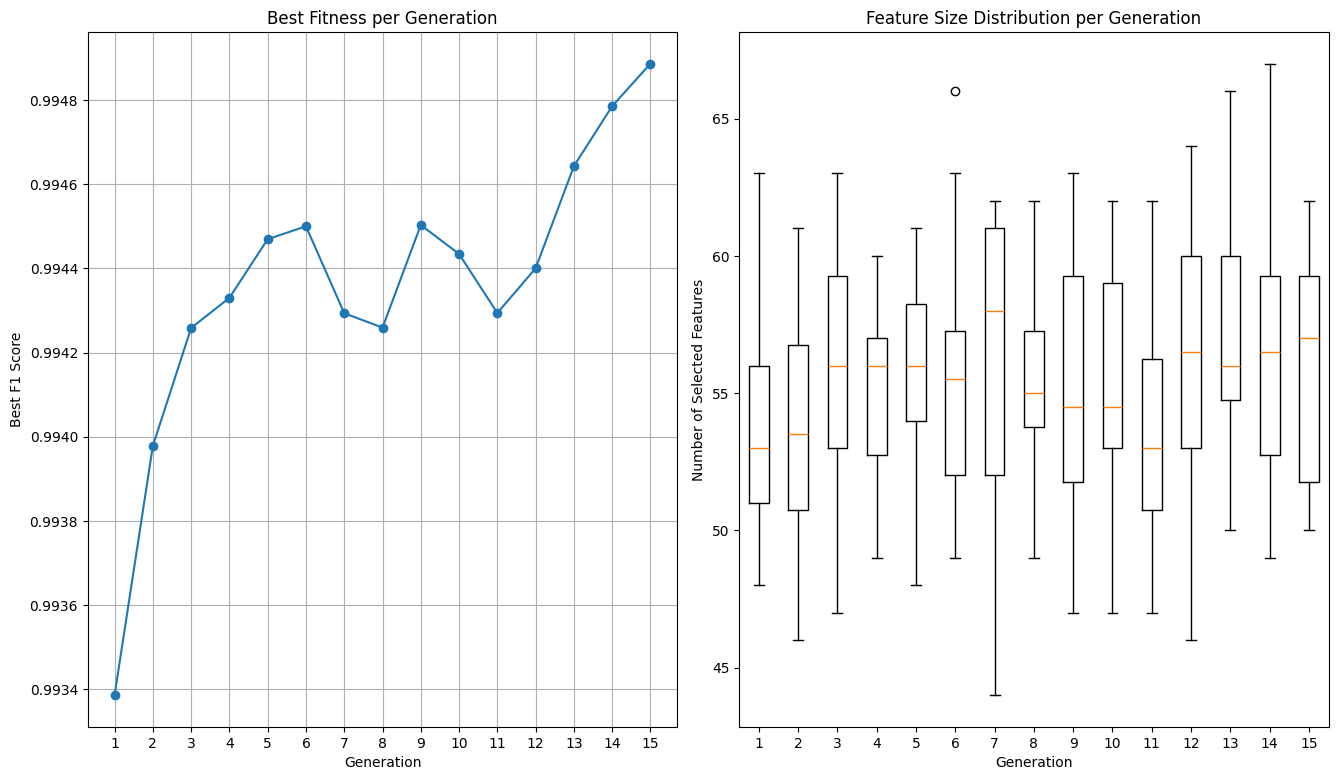

In [35]:
# visualization plots
plt.figure(figsize=(20, 15)) # Create a new figure with width = 20 and height = 15


# generation vs best fitness (f1-score) plot

plt.subplot(2, 3, 1) # no of rows=2, cols=3, position = 1
plt.plot(range(1, numGenerations + 1), best_fitness_history, marker='o')
plt.title('Best Fitness per Generation')
plt.xlabel('Generation')
plt.ylabel('Best F1 Score')
plt.xticks(range(1, numGenerations + 1))
plt.grid(True)


# feature size distribution boxplot
plt.subplot(2, 3, 2)
feature_size_matrix = np.array(feature_size_history)
plt.boxplot(feature_size_matrix.T)
plt.title('Feature Size Distribution per Generation')
plt.xlabel('Generation')
plt.ylabel('Number of Selected Features')
plt.xticks(range(1, numGenerations + 1))

plt.tight_layout()
plt.show()

# Summary: Extracting the Best Solution

## **1. Final Fitness Calculation**
- Evaluates the fitness of all individuals in the final population using `fitnessFunction`.

## **2. Best Solution**
- Identifies the individual with the highest fitness score as the **best solution**.

## **3. Selected Features**
- Extracts the indices of features corresponding to `1` in the best solution.

## **Output**
- Prints the indices of the selected features for the best-performing individual.


In [31]:
# after GA, select the best features
final_fitness = []
for individual in population:
    fitness_value = fitnessFunction(individual)
    final_fitness.append(fitness_value)

final_fitness = np.array(final_fitness)

best_solution = population[np.argmax(final_fitness)]

selected_features = []
for i, bit in enumerate(best_solution):
    if bit == 1:
        selected_features.append(i)


print("Selected Feature Indices:", selected_features)

Selected Feature Indices: [0, 1, 2, 3, 4, 6, 8, 12, 14, 15, 16, 17, 18, 19, 21, 22, 24, 25, 27, 28, 29, 32, 34, 35, 40, 42, 45, 46, 48, 51, 52, 53, 54, 57, 58, 60, 62, 65, 68, 69, 70, 72, 73, 74, 75, 77, 82, 83, 84, 88, 90, 93, 97, 98, 99, 100, 101]


# **Summary: Model Training and Evaluation Workflow**

## **1. Feature Selection**
- Converts feature indices to column names and filters datasets to include only selected features.

## **2. Model Initialization**
- Initializes two models: **Decision Tree Classifier** (random state for reproducibility) and **K-Nearest Neighbors (KNN)** (5 neighbors).

## **3. Metrics Storage**
- Stores evaluation metrics: **Accuracy**, **Precision**, **Recall**, and **F1-Score**.

## **4. Model Training and Evaluation**
- Trains each model on selected features, makes predictions, computes metrics, and logs classification reports.

## **5. Results Storage**
- Saves performance metrics for visualization or further analysis.


In [32]:
# Convert selected feature indices to column names if needed
if isinstance(selected_features[0], int):  # If features are indices
    selected_features = reduced_x_train.columns[selected_features]

X_train_selected = reduced_x_train[selected_features]
X_test_selected = x_test[selected_features]

# Initialize models
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

# Store metrics for visualization
metrics = {'Model': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-Score': []}

# Train and evaluate each model
for model_name, model in models.items():
    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Append metrics
    metrics['Model'].append(model_name)
    metrics['Accuracy'].append(accuracy)
    metrics['Precision'].append(precision)
    metrics['Recall'].append(recall)
    metrics['F1-Score'].append(f1)
    
    print(f"Performance of {model_name}:")
    print(classification_report(y_test, y_pred)) 

Performance of Decision Tree:
              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     15411
         1.0       1.00      0.99      0.99     14293

    accuracy                           1.00     29704
   macro avg       1.00      1.00      1.00     29704
weighted avg       1.00      1.00      1.00     29704

Performance of KNN:
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     15411
         1.0       0.99      0.99      0.99     14293

    accuracy                           0.99     29704
   macro avg       0.99      0.99      0.99     29704
weighted avg       0.99      0.99      0.99     29704



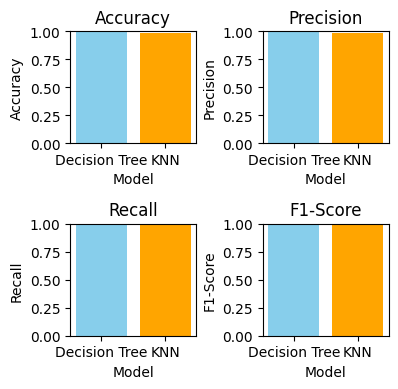

In [33]:
# Visualization of model performance
fig, ax = plt.subplots(2, 2, figsize=(4, 4))
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for i, metric in enumerate(metric_names):
    ax[i // 2, i % 2].bar(metrics['Model'], metrics[metric], color=['skyblue', 'orange'])
    ax[i // 2, i % 2].set_title(metric)
    ax[i // 2, i % 2].set_ylim(0, 1)
    ax[i // 2, i % 2].set_ylabel(metric)
    ax[i // 2, i % 2].set_xlabel('Model')

plt.tight_layout()
plt.show()